# Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)

# Generate Dummy Dataset

In [ ]:
# Create synthetic data (binary classification problem)
# 1000 samples, 2 input features
X_np = np.random.randn(1000, 2)
# Target is 1 if sum of features is positive, else 0
Y_np = (X_np[:, 0] + X_np[:, 1] > 0).astype(np.float32)

# Convert arrays to PyTorch Tensors
X = torch.tensor(X_np, dtype=torch.float32)
Y = torch.tensor(Y_np, dtype=torch.float32).unsqueeze(1)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {Y.shape}")

Features shape: torch.Size([1000, 2])
Labels shape: torch.Size([1000, 1])


# Define Network Architecture

In [ ]:
class SimpleFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleFNN, self).__init__()
        # Linear layer from input to hidden space
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Activation function
        self.relu = nn.ReLU()
        # Linear layer from hidden to output space
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        # Sigmoid transforms output to a probability (0 to 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

# Instantiate model: 2 inputs, 4 hidden neurons, 1 output
model = SimpleFNN(input_dim=2, hidden_dim=4, output_dim=1)
print(model)

SimpleFNN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# Set Loss Function and Optimizer

In [ ]:
# Binary Cross Entropy Loss for binary classification
criterion = nn.BCELoss()

# Adam optimizer with a learning rate of 0.01
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training Loop

In [ ]:
epochs = 100
loss_history = []

for epoch in range(epochs):
    # Reset gradients to zero
    optimizer.zero_grad()

    # Forward pass: compute predictions
    predictions = model(X)

    # Compute the loss metric
    loss = criterion(predictions, Y)

    # Backward pass: compute gradients
    loss.backward()

    # Update parameters (weights and biases)
    optimizer.step()

    # Record history
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.5977
Epoch [20/100], Loss: 0.5331
Epoch [30/100], Loss: 0.4612
Epoch [40/100], Loss: 0.3840
Epoch [50/100], Loss: 0.3107
Epoch [60/100], Loss: 0.2487
Epoch [70/100], Loss: 0.2000
Epoch [80/100], Loss: 0.1638
Epoch [90/100], Loss: 0.1379
Epoch [100/100], Loss: 0.1198


# Plot Training Performance

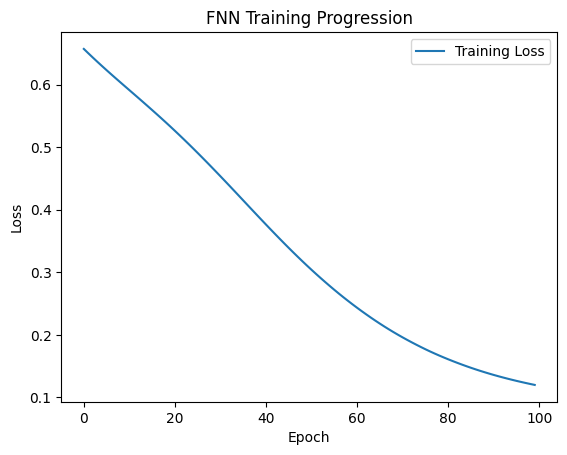

In [ ]:
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FNN Training Progression")
plt.legend()
plt.show()